In [1]:
import os
import sys
repo_path = os.path.abspath(os.path.join(os.getcwd(), "../../"))
sys.path.append(repo_path)

import numpy as np
import matplotlib.pyplot as plt
from utils import load_yaml, convert_weight_to_tensor
from tqdm import tqdm

import dolfinx
import dolfinx.fem.petsc
import ufl
from mpi4py import MPI
import basix.ufl

from data_generation.differential_equations import ElasticityLeastSquares
from train.train_loss import SurrogateLoss
import torch

----------------------------------------
2026-03-02 22:23:55 - Start Program
----------------------------------------


In [2]:
mesh_config_path= repo_path + "/configs/elasticity/config_data/config_mesh.yaml"
function_space_config_path= repo_path + "/configs/elasticity/config_data/config_function_space.yaml"
function_space_finer_config_path = repo_path + "/configs/elasticity/config_data/config_function_space_finer.yaml"
output_reduced_basis_config_path= repo_path + "/configs/elasticity/config_data/config_output_reduced_basis.yaml"
train_dataset_path = repo_path + "/results/elasticity/train_dataset"
test_dataset_path = repo_path + "/results/elasticity/test_dataset"

mesh_args = load_yaml(mesh_config_path)
function_space_args = load_yaml(function_space_config_path)
function_space_finer_args = load_yaml(function_space_finer_config_path)
output_reduced_basis_args = load_yaml(output_reduced_basis_config_path)
elasticity_least_squares = ElasticityLeastSquares(mesh_args, function_space_args)

In [3]:
num_basis_list = [2**i for i in range(10)]
print(f'num basis list: {num_basis_list}')

num basis list: [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]


In [4]:
num_samples = 500
compute_squared_hdiv_h1_norm = elasticity_least_squares.compute_squared_hdiv_h1_norm
mesh = elasticity_least_squares.mesh
Vh = elasticity_least_squares.Vh

In [5]:
reduced_basis_mse_error_record = np.zeros((len(num_basis_list), num_samples))

In [6]:
sigma_u_dof = np.load(test_dataset_path+'/sigma_u_dof.npy')[:num_samples]
pod_basis_dof = np.load(test_dataset_path+'/hdiv_h1_pod_basis_dof.npy')[:,:output_reduced_basis_args['num_basis']] 
reference_reduced_minimizers = np.load(test_dataset_path+'/reference_reduced_minimizers.npy')[:num_samples]

In [7]:
mean_p_dof = np.load(test_dataset_path+'/mean_p_dof.npy')
mean_p_fc = dolfinx.fem.Function(Vh['p'])
mean_p_fc.x.array[:] = mean_p_dof

In [8]:
for i, num_basis in enumerate(tqdm(num_basis_list)):
    reduced_basis_sigma_u_dof = reference_reduced_minimizers[:, :num_basis] @ pod_basis_dof[:, :num_basis].T
    for j, sample_index in enumerate(tqdm(range(num_samples))):
        sigma_u_low_rank_fc = dolfinx.fem.Function(Vh['sigma_u'])
        sigma_u_low_rank_fc.x.array[:] = reduced_basis_sigma_u_dof[j]
        sigma_low_rank_fc = sigma_u_low_rank_fc.sub(0).collapse()
        u_low_rank_fc = sigma_u_low_rank_fc.sub(1).collapse()
        sigma1_low_rank_fc, sigma2_low_rank_fc = ufl.split(sigma_low_rank_fc)
        sigma_low_rank_fc_ = ufl.as_vector((sigma1_low_rank_fc, sigma2_low_rank_fc))


        sigma_u_label_fc = dolfinx.fem.Function(Vh['sigma_u'])
        sigma_u_label_fc.x.array[:] = sigma_u_dof[sample_index]
        sigma_label_fc = sigma_u_label_fc.sub(0).collapse()
        u_label_fc = sigma_u_label_fc.sub(1).collapse()
        sigma1_label_fc, sigma2_label_fc = ufl.split(sigma_label_fc)
        sigma_label_fc_ = ufl.as_vector((sigma1_label_fc, sigma2_label_fc))

        difference_sigma_fc = ufl.as_vector((sigma1_low_rank_fc - sigma1_label_fc, sigma2_low_rank_fc - sigma2_label_fc))
        difference_u_fc = u_low_rank_fc - u_label_fc

        reduced_basis_mse_error_record[i, j] = compute_squared_hdiv_h1_norm(difference_sigma_fc, difference_u_fc, mean_p_fc)

100%|██████████| 10/10 [05:54<00:00, 35.47s/it]


In [9]:
mean_reduced_basis_mse_error_record = np.mean(reduced_basis_mse_error_record, axis=1)

In [10]:
mean_reduced_basis_mse_error_record

array([0.25128842, 0.19126879, 0.12239417, 0.0717273 , 0.03850459,
       0.0213571 , 0.0123788 , 0.00747089, 0.00485341, 0.00354121])

## RB Loss

In [11]:
pod_basis_dof = np.load(test_dataset_path+'/hdiv_h1_pod_basis_dof.npy')[:,:output_reduced_basis_args['num_basis']]
reference_reduced_minimizers = np.load(test_dataset_path+'/reference_reduced_minimizers.npy')[:,:output_reduced_basis_args['num_basis']]

In [12]:
dtype = torch.float64

In [13]:
pod_basis_dof = torch.tensor(pod_basis_dof, dtype=dtype)
reference_reduced_minimizers  = torch.tensor(reference_reduced_minimizers , dtype=dtype)
quadratic_weight = torch.tensor(np.load(test_dataset_path+'/hdiv_h1_quadratic_weight.npy'), dtype=dtype)
linear_weight = torch.tensor(np.load(test_dataset_path+'/hdiv_h1_linear_weight.npy'), dtype=dtype)
bias = torch.tensor(np.load(test_dataset_path+'/hdiv_h1_bias.npy'), dtype=dtype)

In [14]:
reduced_weight_list = []
for i in range(len(quadratic_weight)):
    reduced_weight = {}
    reduced_weight['quadratic'] = quadratic_weight[i]
    reduced_weight['linear'] = linear_weight[i]
    reduced_weight['bias'] = bias[i]
    reduced_weight_list.append(reduced_weight)

In [15]:
surrogate_loss = SurrogateLoss(reduced_weight_list)

In [16]:
num_samples = 500
num_basis_list = [2**i for i in range(10)]
print(f'num basis list: {num_basis_list}')
reference_surrogate_loss_record = np.zeros((len(num_basis_list), num_samples))

num basis list: [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]


In [17]:
for i, num_basis in enumerate(num_basis_list):
    for j, sample_index in enumerate(range(num_samples)):
        reference_loss = surrogate_loss(reference_reduced_minimizers[sample_index], sample_index, sub_dim=num_basis)
        reference_surrogate_loss_record[i, j] = reference_loss.item()

In [18]:
mean_reference_surrogate_loss_record = np.mean(reference_surrogate_loss_record, axis=1)

## FE loss

In [19]:
p_dof = np.load(test_dataset_path+'/p_dof.npy')[:num_samples]

In [20]:
torch_dtype = {
    'float16': torch.float16,
    'float32': torch.float32,
    'float64': torch.float64,
}

In [21]:
reference_loss_list = []
for i in tqdm(range(num_samples)):
    p_fc = dolfinx.fem.Function(Vh['p'], dtype='float64')  
    p_fc.x.array[:] = p_dof[i]
    weight = elasticity_least_squares.compute_weight(p_fc)
    weight_tensor = convert_weight_to_tensor(weight, dtype=torch_dtype['float64'])

    y = sigma_u_dof[i]
    y = torch.tensor(y, dtype=torch_dtype['float64'])
    reference_loss = torch.dot(y, weight_tensor['A00'] @ y) + 2*torch.dot(y, weight_tensor['A01'])  + weight_tensor['A11']
    print(f'reference loss: {reference_loss.item()}')
    reference_loss_list.append(reference_loss.item())

  0%|          | 1/500 [00:05<42:06,  5.06s/it]

reference loss: 0.00020366027570628553


  0%|          | 2/500 [00:09<37:03,  4.47s/it]

reference loss: 0.0007820815547369686


  1%|          | 3/500 [00:12<34:17,  4.14s/it]

...

reference loss: 0.0004890818856305157


100%|█████████▉| 499/500 [31:47<00:03,  3.82s/it]

reference loss: 0.000696264104304567


100%|██████████| 500/500 [31:51<00:00,  3.82s/it]

reference loss: 0.001194032260398603


In [22]:
loss_diff = mean_reference_surrogate_loss_record - np.mean(reference_loss_list).item()

In [23]:
loss_diff

array([0.35914259, 0.24953862, 0.14501692, 0.07454755, 0.0382802 ,
       0.02019031, 0.01098709, 0.00593642, 0.00320489, 0.00181211])

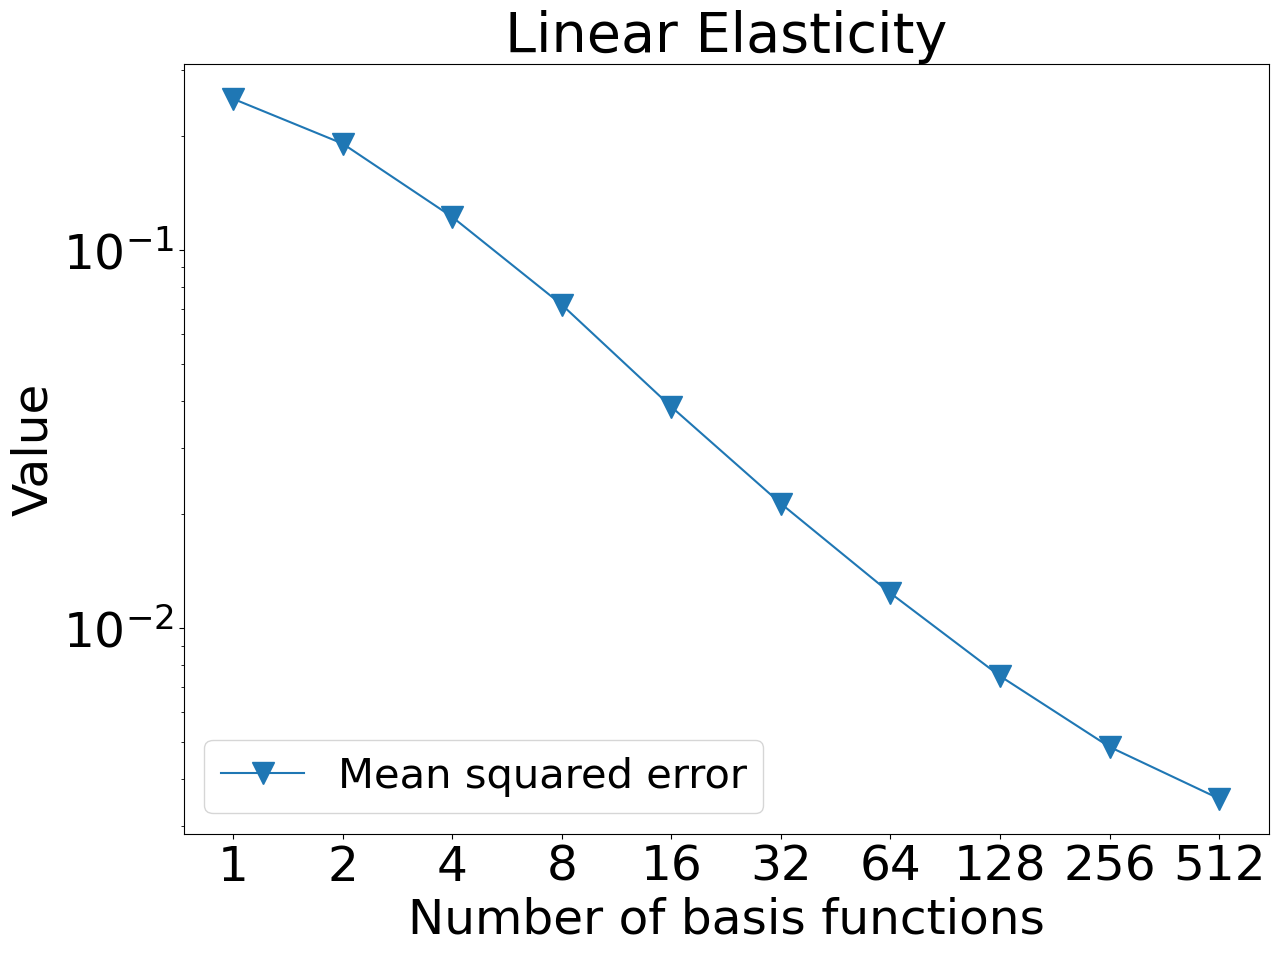

In [24]:
plt.figure(figsize=(14,10))
plt.plot(num_basis_list, mean_reduced_basis_mse_error_record, marker='v', markersize=16, label='Mean squared error')
# plt.plot(num_basis_list, loss_diff, marker='^', markersize=16, label='Mean of RB-FE loss difference')
plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.xlabel('Number of basis functions', fontsize=35)
plt.ylabel('Value',fontsize=35)
plt.xticks(num_basis_list, num_basis_list, fontsize=35)
plt.yticks(fontsize=35)
plt.legend(fontsize=30, loc='lower left')
plt.title('Linear Elasticity', fontsize=40)
# plt.savefig(os.path.join(test_dataset_path, "analysis_loss_diff_and_mse_error.png"), dpi=300, bbox_inches='tight')
plt.show()